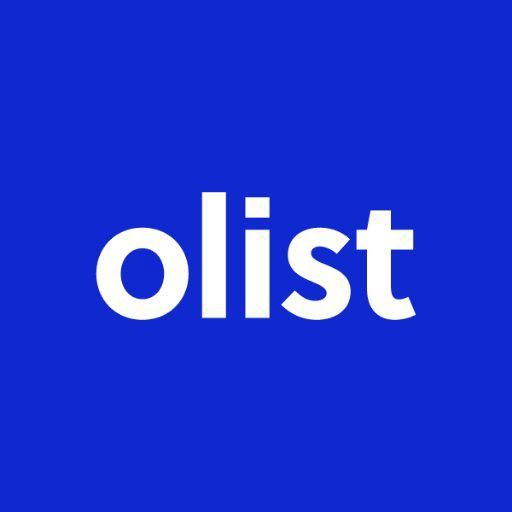

# Olist E-commerce Data Analysis

## Project Objective

This project analyzes the Olist e-commerce dataset to understand sales performance, customer behavior, payment preferences, delivery performance, and customer satisfaction.

The analysis uses SQLite for data extraction, Pandas for data cleaning and analysis, and Matplotlib for data visualization.

## Business Questions

1. How do orders change over time?
2. Which product categories generate the most sales?
3. Which payment methods contribute the most payment value?
4. Which customer states have the highest number of orders?



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3

In [15]:
conn= sqlite3.connect("/content/olist.sqlite")

In [16]:
tables=pd.read_sql_query("""
SELECT name
FROM sqlite_master
WHERE type = 'table';
""", conn)

tables

,name
0,product_category_name_translation
1,sellers
2,customers
3,geolocation
4,order_items
5,order_payments
6,order_reviews
7,orders
8,products
9,leads_qualified


In [34]:
orders = pd.read_sql_query(
    "SELECT * FROM orders;", conn)

order_items = pd.read_sql_query(
    "SELECT * FROM order_items;",conn)

products = pd.read_sql_query(
    "SELECT * FROM products;",conn)

customers = pd.read_sql_query(
    "SELECT * FROM customers;",conn)

reviews = pd.read_sql_query(
    "SELECT * FROM order_reviews;",conn)

payments = pd.read_sql_query(
    "SELECT * FROM order_payments;",conn)

In [35]:
print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("products:", products.shape)
print("customers:", customers.shape)
print("reviews:", reviews.shape)
print("payments:", payments.shape)

orders: (99441, 8)
order_items: (112650, 7)
products: (32951, 9)
customers: (99441, 5)
reviews: (99224, 7)
payments: (103886, 5)


#Data Cleaning

In [36]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

print("Date columns converted.")

Date columns converted.


In [37]:
missing_orders = orders.isna().sum().sort_values(
    ascending=False
)

display(
    missing_orders[missing_orders > 0]
)

,0
order_delivered_customer_date,2965
order_delivered_carrier_date,1783
order_approved_at,160


In [38]:
print(
    "Duplicate rows in orders:",
    orders.duplicated().sum()
)

print(
    "Duplicate order_id values:",
    orders["order_id"].duplicated().sum()
)

print(
    "Duplicate review_id values:",
    reviews["review_id"].duplicated().sum()
)

Duplicate rows in orders: 0
Duplicate order_id values: 0
Duplicate review_id values: 814


In [39]:
delivered = orders[
    (orders["order_status"] == "delivered") &
    orders["order_delivered_customer_date"].notna() &
    orders["order_estimated_delivery_date"].notna()
].copy()

In [40]:
delivered["delivery_days"] = (
    delivered["order_delivered_customer_date"]
    - delivered["order_purchase_timestamp"]
).dt.total_seconds() / 86400

In [44]:
delivered["delay_days"] = (
    delivered["order_delivered_customer_date"]
    - delivered["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

In [45]:
delivered["delivery_group"] = delivered["delay_days"].apply(
    lambda x: "Late" if x > 0 else "On time / Early"
)

In [51]:
total_orders = orders["order_id"].nunique()

unique_customers = customers["customer_unique_id"].nunique()

total_payment_value = payments["payment_value"].sum()

avg_order_payment = (
    payments.groupby("order_id")["payment_value"].sum().mean()
)

late_rate = (
    delivered["delay_days"] > 0
).mean()

avg_review = reviews["review_score"].mean()

print(f"Total orders: {total_orders:,}")
print(f"Unique customers: {unique_customers:,}")
print(f"Total payment value: $ {total_payment_value:,.2f}")
print(f"Average order payment value: $ {avg_order_payment:,.2f}")
print(f"Late delivery rate: {late_rate:.2%}")
print(f"Average review score: {avg_review:.2f} / 5")

Total orders: 99,441
Unique customers: 96,096
Total payment value: $ 16,008,872.12
Average order payment value: $ 160.99
Late delivery rate: 8.11%
Average review score: 4.09 / 5


#EDA

In [52]:
#How do orders change over time?
monthly_orders = pd.read_sql_query("""
SELECT
    substr(order_purchase_timestamp, 1, 7) AS month,
    COUNT(*) AS total_orders
FROM orders
GROUP BY 1
ORDER BY 1;
""", conn)

display(monthly_orders)

,month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


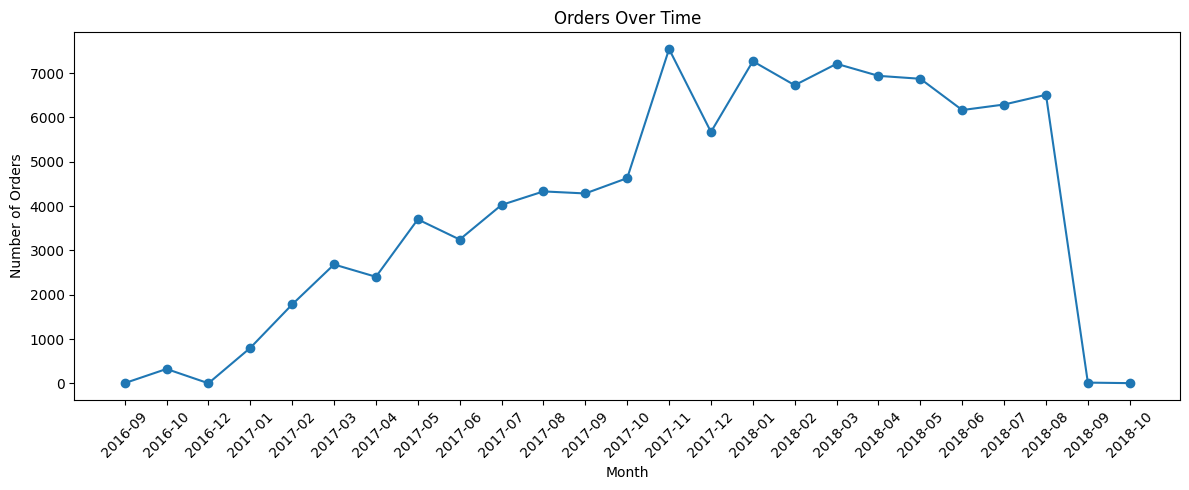

In [53]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_orders["month"],
    monthly_orders["total_orders"],
    marker="o"
)

plt.title("Orders Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [55]:
#Which product categories generate the most sales?
category_sales = pd.read_sql_query("""
SELECT
    COALESCE(
        p.product_category_name,
        'unknown'
    ) AS category,
    SUM(oi.price) AS sales_value

FROM order_items oi

LEFT JOIN products p
    ON oi.product_id = p.product_id

GROUP BY 1

ORDER BY sales_value DESC

LIMIT 10;
""", conn)
category_sales["sales_value"] = (
    category_sales["sales_value"].round(2)
)

display(category_sales)

,category,sales_value
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


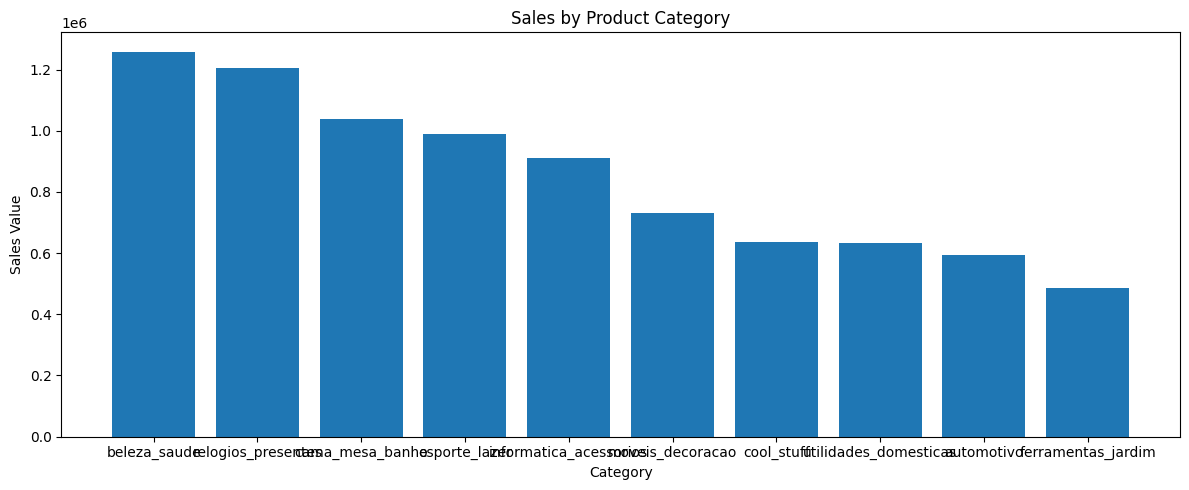

In [57]:
plt.figure(figsize=(12, 5))

plt.bar(
    category_sales["category"],
    category_sales["sales_value"]
)

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales Value")

plt.tight_layout()
plt.show()

In [58]:
#Which payment methods contribute the most value?
payment_value = pd.read_sql_query("""
SELECT
    payment_type,
    SUM(payment_value) AS total_value
FROM order_payments
GROUP BY 1
ORDER BY 2 DESC;
""", conn)

display(payment_value)

,payment_type,total_value
0,credit_card,12542084.19
1,boleto,2869361.27
2,voucher,379436.87
3,debit_card,217989.79
4,not_defined,0.00


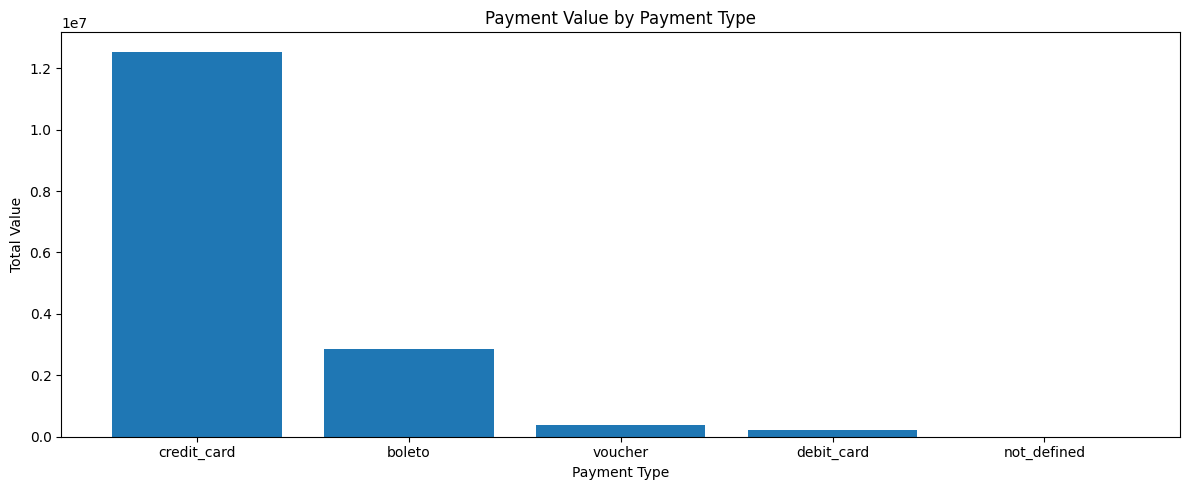

In [59]:
plt.figure(figsize=(12, 5))
plt.bar(payment_value["payment_type"], payment_value["total_value"])
plt.title("Payment Value by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Total Value")
plt.tight_layout()
plt.show()

In [60]:
#Which payment methods contribute the most value?
customer_orders = pd.read_sql_query("""
SELECT
    c.customer_state,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
GROUP BY 1
ORDER BY 2 DESC;
""", conn)

display(customer_orders)

,customer_state,total_orders
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


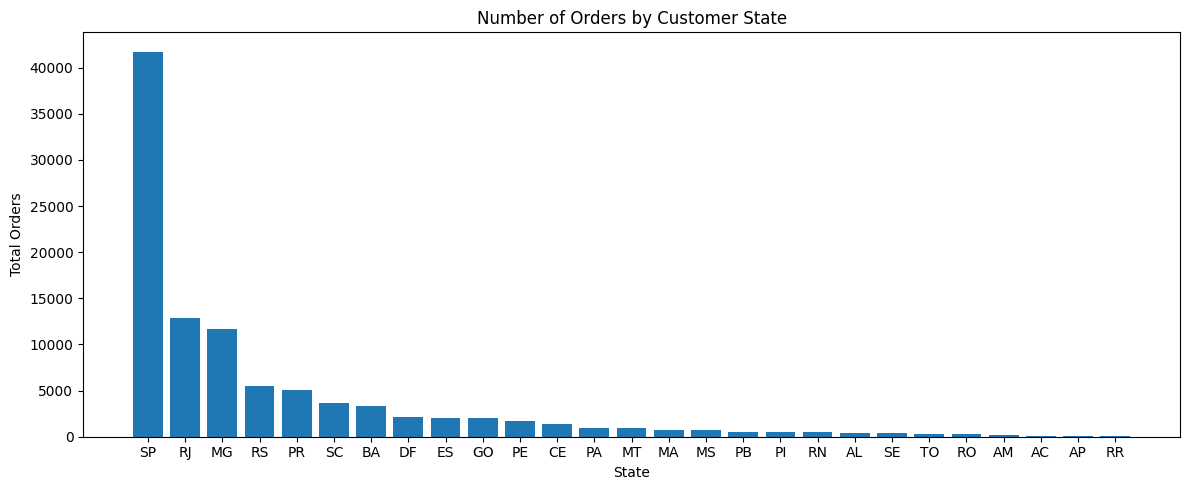

In [61]:
plt.figure(figsize=(12, 5))
plt.bar(customer_orders["customer_state"], customer_orders["total_orders"])
plt.title("Number of Orders by Customer State")
plt.xlabel("State")
plt.ylabel("Total Orders")
plt.tight_layout()
plt.show()

# Final Project Summary

## Key Findings

* Order volume increased substantially over the observed period, with noticeable monthly variation.
* A small group of product categories generated a large share of item sales.
* Credit card was the dominant payment type by payment value.
* Customer orders were concentrated in a limited number of states.

## Business Takeaways

The analysis suggests that sales concentration, regional demand, payment behavior, and delivery performance are important areas for e-commerce monitoring.

Delivery performance deserves particular attention because late orders show noticeably lower customer satisfaction scores in the dataset.
